# Домашнее задание: Кластеризация текстов

Сеть супермаркетов «Перекрёсток» собирает отзывы от клиентов по разным каналам: мобильное приложение, сайт, чековые анкеты. Отзывы включают как положительные оценки, так и жалобы — на персонал, доставку, свежесть товаров, наличие и т.д.

**Бизнес сталкивается с проблемой**:

* Отзывов слишком много, они разнообразны по формулировкам.
* Ручная обработка отзывов — долгая и неэффективная.
* Нельзя быстро понять, о чём говорят клиенты, какие темы повторяются.

**Цель бизнеса**:

* Автоматически группировать отзывы по смыслу, чтобы:
* обнаруживать повторяющиеся проблемы (например, "не тот товар", "просрочка"),
* оценивать работу конкретных магазинов и доставок,
* поддерживать продуктовые и операционные улучшения на основе обратной связи.



In [1]:
!pip freeze > start_env.txt

# Читаем данные

Скачаем данные по отзывам на продукты. Предобработаем их и отфильтруем небольшое количество, чтобы потрогать руками различные алгоритмы, рассмотренные на лекции.

Для упрощения анализа кластеров и возможности здраво оценить, насколько результаты приемлемы, разделим данные на две явно разделенные по смыслу (во всяком случае, в среднем) группы: отзывы с максимальной оценкой и отзывы с минимальной оценкой.

In [2]:
# # помогает с ошибкой чтения датасета с HF
# !pip install fsspec==2023.6.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 5.8 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.0
    Uninstalling fsspec-2025.3.0:
      Successfully uninstalled fsspec-2025.3.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2023.6.0 which is incompatible.


In [11]:
from datasets import load_dataset

# Загружаем train-часть датасета
dataset = load_dataset("lapki/perekrestok-reviews", split="train")
print(dataset)

Dataset({
    features: ['product_id', 'product_name', 'product_category', 'product_price', 'review_id', 'review_author', 'review_text', 'rating'],
    num_rows: 642682
})


In [12]:
from datasets import load_dataset
import pandas as pd

N = 10000
df = dataset.to_pandas()
df = df[["review_id", "product_category", "product_name", "review_text", "rating"]]
df = df.sort_values(by="review_id").head(N)
df.head(2)

,review_id,product_category,product_name,review_text,rating
128218,1493,Для мам и детей,Сок Сады Придонья Яблоко зеленое 125мл,Самые лучшие соки. Всегда беру детям только их...,5.0
426797,1496,Сладости,Пастила Белевская Пастильная Мануфактура Класс...,"Вкуснее, чем у известных конкурентов.",5.0


In [13]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Применяем очистку
df["clean_text"] = df["review_text"].apply(clean_text)
df.head(2)

,review_id,product_category,product_name,review_text,rating,clean_text
128218,1493,Для мам и детей,Сок Сады Придонья Яблоко зеленое 125мл,Самые лучшие соки. Всегда беру детям только их...,5.0,самые лучшие соки. всегда беру детям только их...
426797,1496,Сладости,Пастила Белевская Пастильная Мануфактура Класс...,"Вкуснее, чем у известных конкурентов.",5.0,"вкуснее, чем у известных конкурентов."


In [14]:
neg = df[df["rating"] == 1.0].sort_values(by="review_id")[:500]
pos = df[df["rating"] == 5.0].sort_values(by="review_id")[:500]
cut_df = pd.concat([neg, pos]).reset_index(drop=True)
cut_df["rating"].value_counts()

,count
rating,
1.0,500
5.0,500


In [15]:
cut_df.head(2)

,review_id,product_category,product_name,review_text,rating,clean_text
0,3972,"Чай, кофе, сахар",Сахар песок белый 1кг,запекала сахар вместе с дыней. дыня совсем не ...,1.0,запекала сахар вместе с дыней. дыня совсем не ...
1,4462,"Чай, кофе, сахар",Кофе молотый Julius Meinl Prasident 250г,Почти без запаха.,1.0,почти без запаха.


# Алгоритмы визуализации - 5 баллов

Реализуйте функции для сжатия эмбеддингов до двумерного пространства с помощью подходов t-SNE и UMAP. Каждая функция должна строить изображения поданных на вход эмбеддингов в пространстве, а также учитывать, какое расстояние между эмбеддингами мы считаем (евклидово или косинусное).

Протестируйте их на небольшом семпле.

In [6]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import torch
import seaborn as sns
import numpy as np
import umap


# Можно реализовать через одну функцию, но для тестирования разных сетапов было удобно делать две отдельно

# Визуализация через t-SNE
def plot_embeddings(embeds, title, metric="euclidean"):
    # ---- Ваш код здесь ----
    print("строим tsne")
    if isinstance(embeds, torch.Tensor):
        embeds = embeds.detach().cpu().numpy()

    perplexity = int(np.clip(np.sqrt(embeds.shape[0]), 5, 50))
    tsne = TSNE(
        n_components=2,
        init="pca",
        learning_rate="auto",
        metric=metric,
        perplexity=perplexity
    )

    embeddings_2d = tsne.fit_transform(embeds)

    plt.figure(figsize=(8, 6))
    plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], s=5, alpha=0.7)
    plt.title(title)
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.grid(True)
    plt.show()
    # ---- Конец кода ----


    plt.show()


# Визуализация через UMAP
def plot_embeddings_umap(embeds, title, metric="euclidean"):
    if isinstance(embeds, torch.Tensor):
        embeds = embeds.detach().cpu().numpy()
    # ---- Ваш код здесь ----
    print("строим umap")

    reducer = umap.UMAP(
        n_components=2,
        metric=metric,
        random_state=42
    )

    embeddings_2d = reducer.fit_transform(embeds)

    plt.figure(figsize=(8, 6))
    plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], s=5, alpha=0.7)
    plt.title(title)
    plt.xlabel("UMAP-1")
    plt.ylabel("UMAP-2")
    plt.grid(True)
    plt.show()
    # ---- Конец кода ----


строим tsne


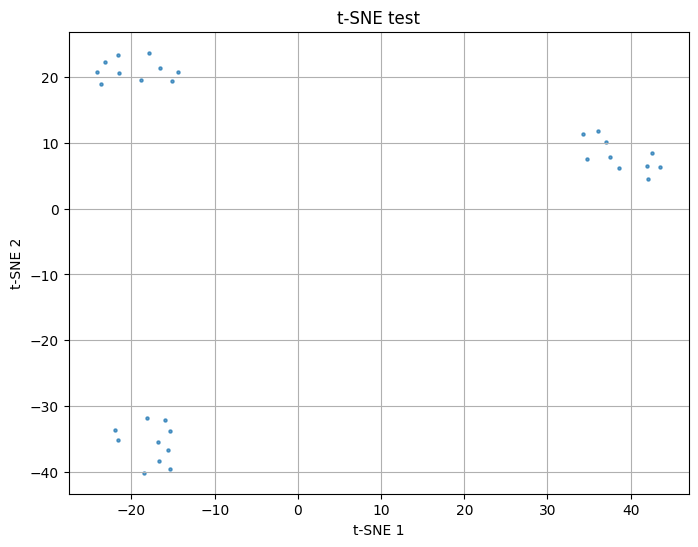

строим umap


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


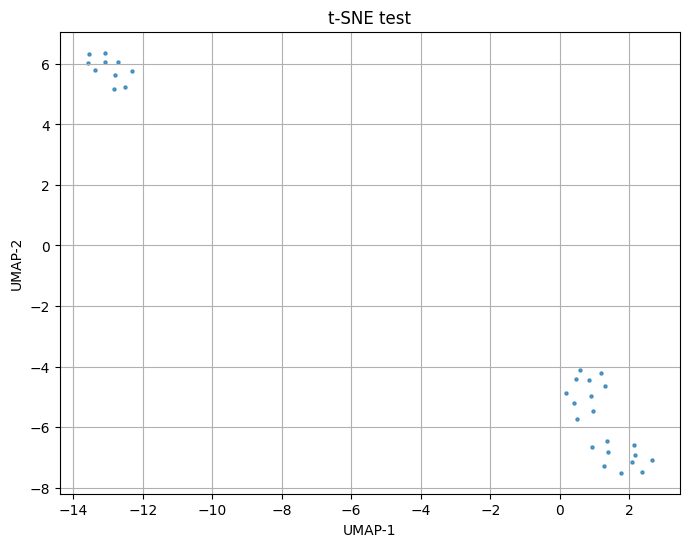

In [7]:
embs = np.concatenate([np.random.rand(10, 3), np.random.rand(10, 3) + 2, np.random.rand(10, 3) - 1], axis=0)
plot_embeddings(embs, "t-SNE test", metric="euclidean")
plot_embeddings_umap(embs, "t-SNE test", metric="euclidean")

# Зависимость кластеров от эмбеддера - 5 баллов

В данной части предлагается оценить, насколько эмбеддер на качество кластеризации может влиять:
а) эмбеддер
б) выбранная метрика расстояния

Возьмите следующие две модели:
1) "ai-forever/FRIDA" -- хороший качественный эмбеддер
2) "cointegrated/rubert-tiny2" -- достаточно слабый по современным меркам эмбеддер

Реализуйте подгрузку этой модели через класс SentenceTransformer и постройте визуализацию кластеров
а) через функцию с UMAP и через функцию с t-SNE
б) и для каждого варианта -- визуализацию с евклидовым расстоянием и с косинусным расстоянием
в) и для каждого варианта -- с эмбеддером FRIDA и с эмбеддером rubert-tiny2

Итого должно получиться 8 графиков. Сделайте выводы, какой эмбеддер визуально разграничивает данные лучше.

In [65]:
cut_df["clean_text"].isna().sum()

np.int64(0)

загружаем две модели и считаем эмбеддинги для каждой от texts, а затем рисуем графики функциями выше


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/509 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Строим график: FRIDA | t-SNE | metric=euclidean
строим tsne


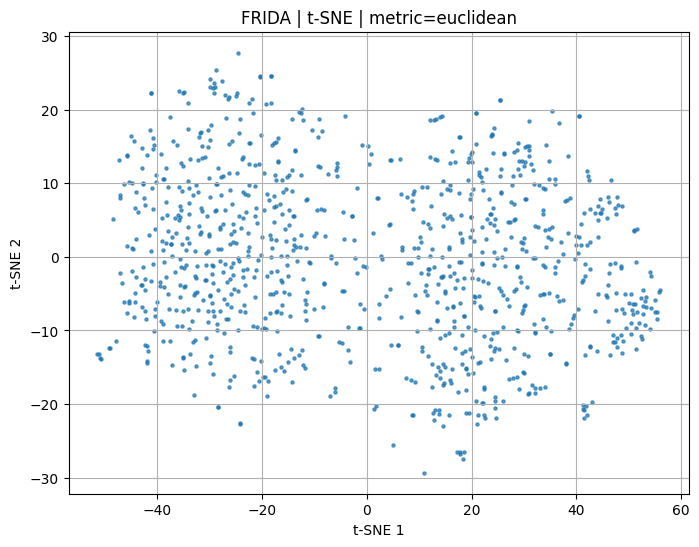

Строим график: FRIDA | t-SNE | metric=cosine
строим tsne


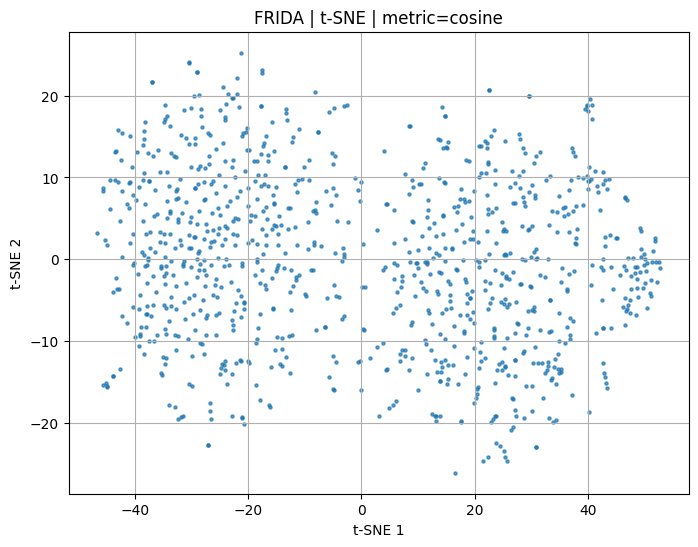

Строим график: FRIDA | UMAP | metric=euclidean
строим umap


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


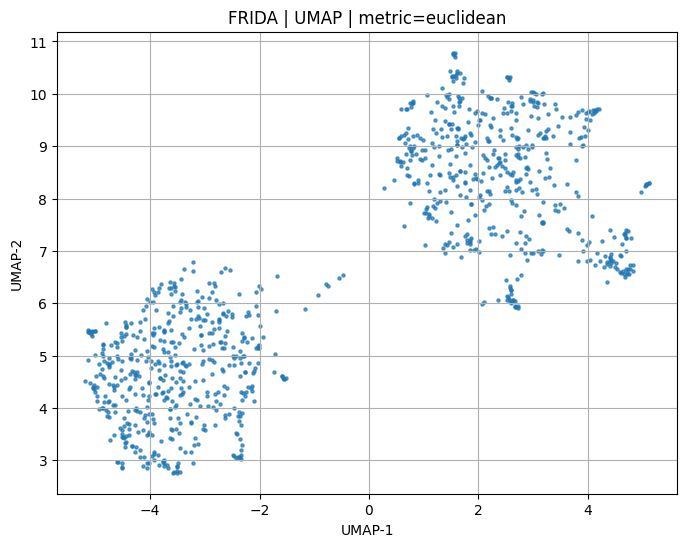

Строим график: FRIDA | UMAP | metric=cosine
строим umap


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


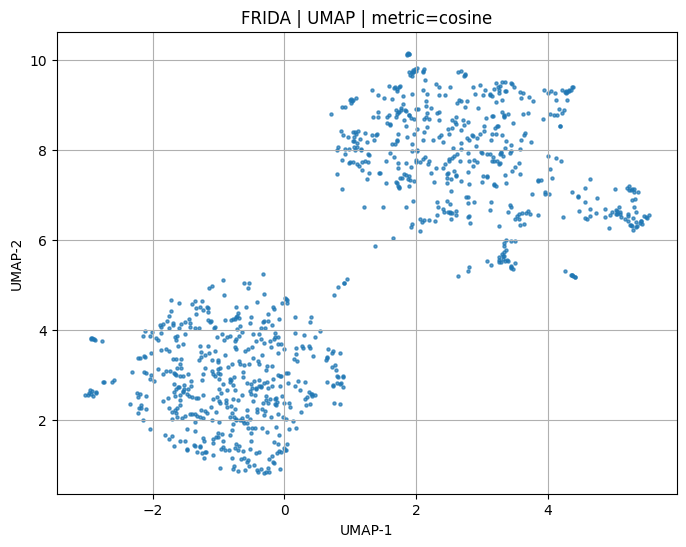

Строим график: rubert-tiny2 | t-SNE | metric=euclidean
строим tsne


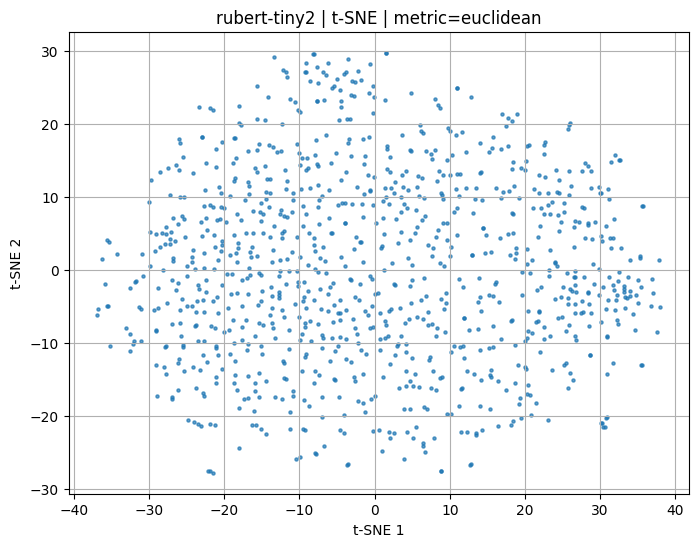

Строим график: rubert-tiny2 | t-SNE | metric=cosine
строим tsne


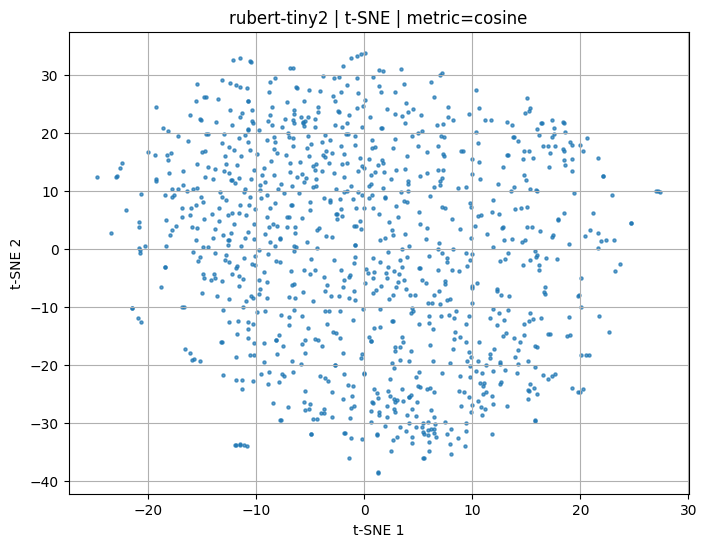

Строим график: rubert-tiny2 | UMAP | metric=euclidean
строим umap


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


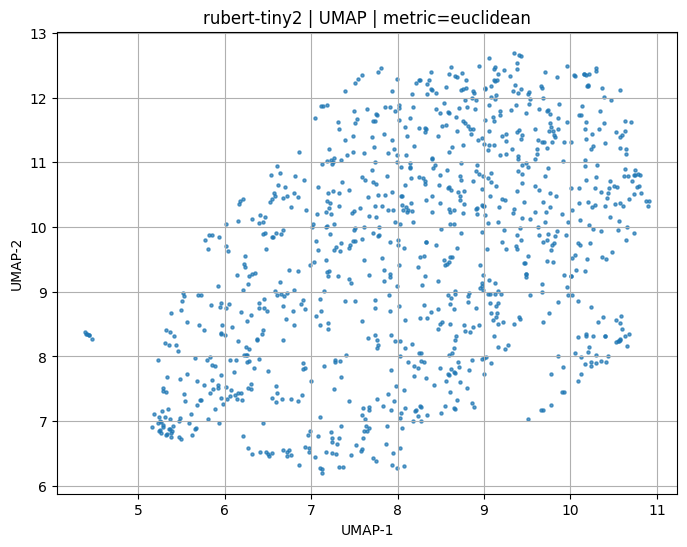

Строим график: rubert-tiny2 | UMAP | metric=cosine
строим umap


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


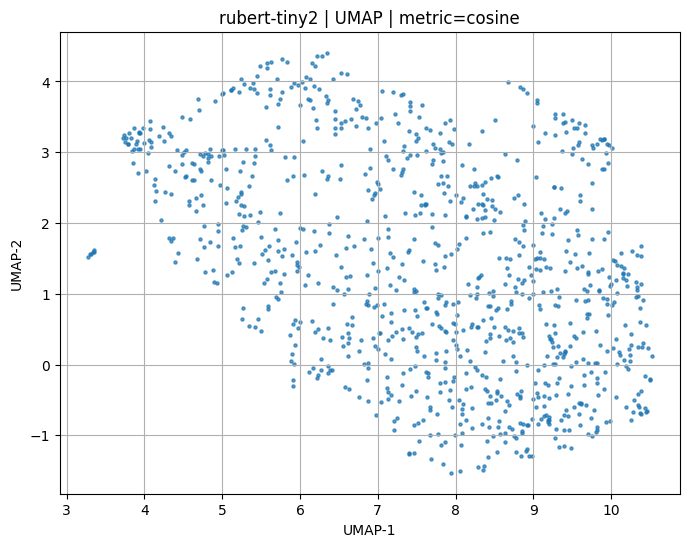

In [8]:
from sentence_transformers import SentenceTransformer

texts = cut_df["clean_text"].values

# ---- Ваш код здесь ----
print("загружаем две модели и считаем эмбеддинги для каждой от texts, а затем рисуем графики функциями выше")

models = {
    "FRIDA": "ai-forever/FRIDA",
    "rubert-tiny2": "cointegrated/rubert-tiny2",
}

reducers = {
    "t-SNE": plot_embeddings,
    "UMAP": plot_embeddings_umap,
}

metrics = ["euclidean", "cosine"]

embeddings = {}

for model_name, model_path in models.items():
    model = SentenceTransformer(model_path)

    embeds = model.encode(
        texts,
        batch_size=32,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=False
    )

    embeddings[model_name] = embeds


for model_name, embeds in embeddings.items():
    for reducer_name, plot_func in reducers.items():
        for metric in metrics:
            title = f"{model_name} | {reducer_name} | metric={metric}"
            print(f"Строим график: {title}")
            plot_func(embeds, title=title, metric=metric)

# FRIDA выдала эмбеддинги, в которых кластера видны намного лучше. Видно два отдельных кластера
# rubert-tiny2 выдала плохие эмбеддинги. Вообще визуально не видно никаких кластеров. Трудно увидеть какие-либо кластеры. Наверное, потому что модель более маленькая

# По графикам и метрике: не сильно увидел различия в метриках. По алгоритмам UMAP дал более различимые кластеры.
# ---- Конец кода ----



# Зависимость кластеров от алгоритма кластеризации - 10 баллов

Реализуйте кластеризацию выбранных нами текстов через алгоритмы KMeans, MiniBatchKMeans, HDBSCAN. Сравните эти алгоритмов визуально и по метрикам. В качестве метрик используйте silhouette_score для безотносительной оценки качества и adjusted_rand_score для оценки качества относительно рейтинга (1.0 или 5.0). Визуализацию делайте с помощью UMAP.

compare_clusterers принимает на вход кластеризуемые эмбеддинги и, опционально, референсные значения кластеров (в нашем случае -- принадлежность к рейтингу). Функция должна отрисовывать кластера в пространстве для трех алгоритмов и возвращать метрики по каждому из них в виде словаря.

In [41]:
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.cluster import HDBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score
import umap
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm


def compare_clusterers(embeddings, true_labels=None, n_clusters=5, umap_embeddings=False):
    results = {}


    # ---- Ваш код здесь ----
    print("кластеризуем и тремя моделями и считаем метрики силуэт и ari")

    if hasattr(embeddings, "detach"):
        embeddings = embeddings.detach().cpu().numpy()

    embeddings = np.asarray(embeddings)

    reducer = umap.UMAP(
        n_components=2,
        metric="cosine",
        random_state=42
    )
    embeddings_2d = reducer.fit_transform(embeddings)

    if umap_embeddings:
        reducer_emb = umap.UMAP(
            n_components=5,
            n_neighbors=15,
            min_dist=0.0,
            metric="cosine",
            random_state=42
        )
        embeddings = reducer_emb.fit_transform(embeddings)


    clusterers = {
        "KMeans": KMeans(
            n_clusters=n_clusters,
            random_state=42,
            n_init="auto"
        ),
        "MiniBatchKMeans": MiniBatchKMeans(
            n_clusters=n_clusters,
            random_state=42,
            n_init="auto",
            batch_size=256
        ),
        "HDBSCAN": HDBSCAN(
            min_cluster_size=30,
            min_samples=5,
            # metric="cosine",
            # cluster_selection_method="leaf"
        )
    }

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for ax, (name, clusterer) in zip(axes, clusterers.items()):
        print(f"Кластеризуем через {name}")
        labels = clusterer.fit_predict(embeddings)

        unique_labels = set(labels)
        n_found_clusters = len(unique_labels - {-1})

        results[name] = {
            "n_clusters": n_found_clusters,
            "n_noise": int(np.sum(labels == -1))
        }

        valid_mask = labels != -1

        if len(set(labels[valid_mask])) > 1:
            results[name]["silhouette_score"] = silhouette_score(
                embeddings[valid_mask],
                labels[valid_mask],
                metric="cosine"
            )
        else:
            results[name]["silhouette_score"] = None

        if true_labels is not None:
            true_labels_arr = np.asarray(true_labels)

            if len(true_labels_arr) != len(labels):
                raise ValueError("true_labels и embeddings должны иметь одинаковую длину")

            results[name]["adjusted_rand_score"] = adjusted_rand_score(
                true_labels_arr,
                labels
            )

        scatter = ax.scatter(
            embeddings_2d[:, 0],
            embeddings_2d[:, 1],
            c=labels,
            s=8,
            alpha=0.75,
            cmap="tab10"
        )

        ax.set_title(f"{name}\nclusters={n_found_clusters}, noise={results[name]['n_noise']}")
        ax.set_xlabel("UMAP-1")
        ax.set_ylabel("UMAP-2")
        ax.grid(True)

    plt.tight_layout()
    # ---- Конец кода ----

    plt.show()

    return results

кластеризуем и тремя моделями и считаем метрики силуэт и ari


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Кластеризуем через KMeans
Кластеризуем через MiniBatchKMeans
Кластеризуем через HDBSCAN


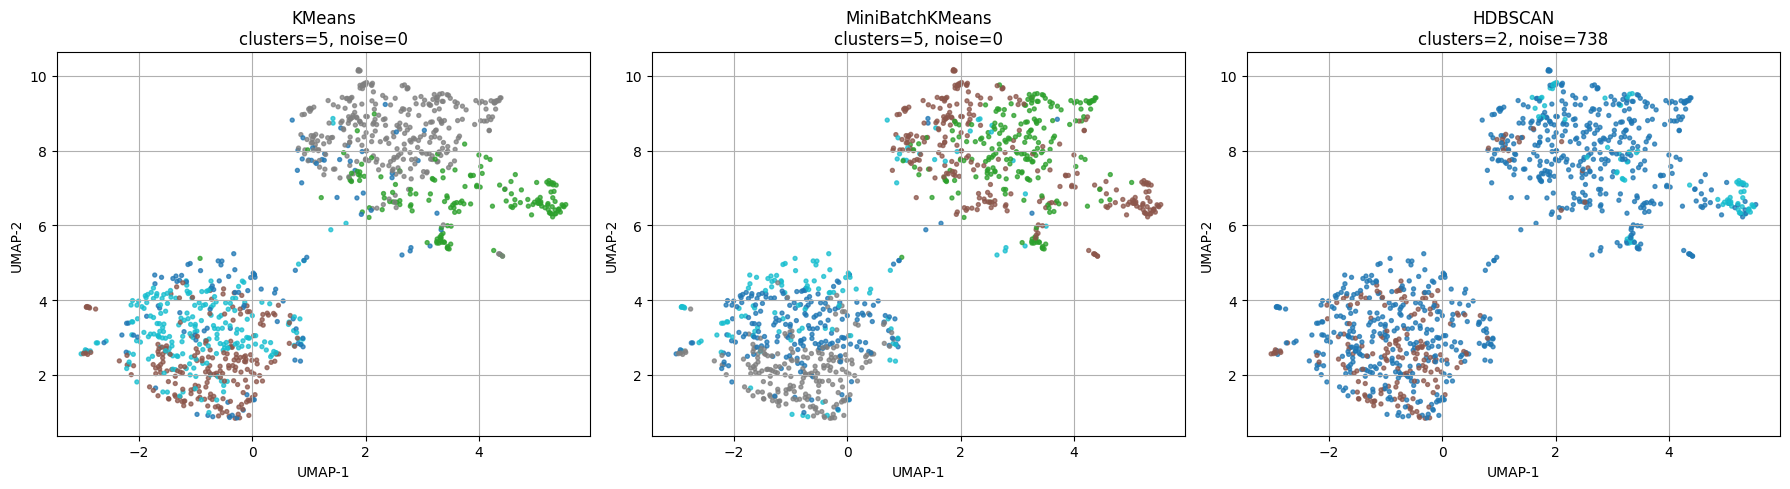

{'KMeans': {'n_clusters': 5,
  'n_noise': 0,
  'silhouette_score': np.float32(0.039991684),
  'adjusted_rand_score': 0.4050000096647232},
 'MiniBatchKMeans': {'n_clusters': 5,
  'n_noise': 0,
  'silhouette_score': np.float32(0.03012406),
  'adjusted_rand_score': 0.3782338958541562},
 'HDBSCAN': {'n_clusters': 2,
  'n_noise': 738,
  'silhouette_score': np.float32(0.24317336),
  'adjusted_rand_score': 0.06317368582349905}}

In [42]:
# embeddings: np.array, shape = (n_samples, embedding_dim)
# true_labels: list или np.array (опционально)

good_embeds = embeddings['FRIDA']
true_labels = (cut_df["rating"] == 5.0).apply(int)
results = compare_clusterers(good_embeds, true_labels=true_labels, n_clusters=5)
results

кластеризуем и тремя моделями и считаем метрики силуэт и ari


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Кластеризуем через KMeans
Кластеризуем через MiniBatchKMeans
Кластеризуем через HDBSCAN


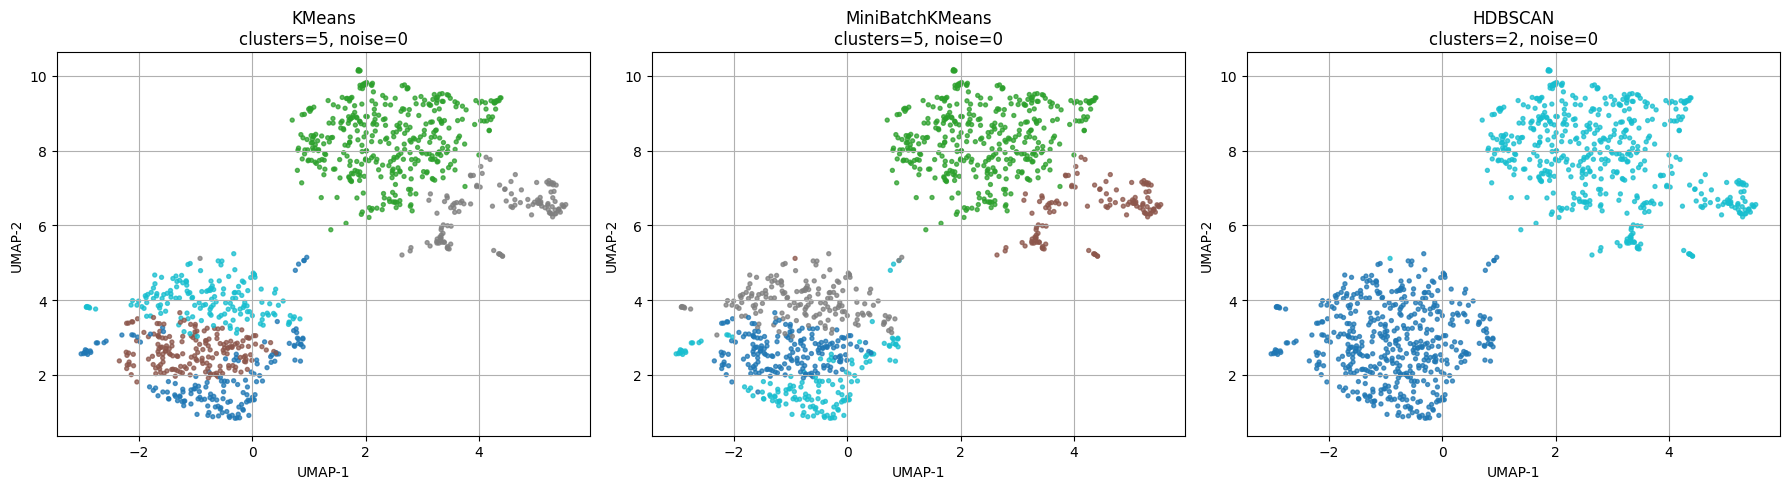

{'KMeans': {'n_clusters': 5,
  'n_noise': 0,
  'silhouette_score': np.float32(0.47307286),
  'adjusted_rand_score': 0.4529244537713324},
 'MiniBatchKMeans': {'n_clusters': 5,
  'n_noise': 0,
  'silhouette_score': np.float32(0.47912157),
  'adjusted_rand_score': 0.45352591059975106},
 'HDBSCAN': {'n_clusters': 2,
  'n_noise': 0,
  'silhouette_score': np.float32(0.96484435),
  'adjusted_rand_score': 0.9215214630165386}}

In [44]:
# embeddings: np.array, shape = (n_samples, embedding_dim)
# true_labels: list или np.array (опционально)

good_embeds = embeddings['FRIDA']
true_labels = (cut_df["rating"] == 5.0).apply(int)
results = compare_clusterers(good_embeds, true_labels=true_labels, n_clusters=5, umap_embeddings=True)
results

In [47]:
print(
'''UMAP перед кластеризацией значительно улучшает качество: silhouette заметно вырос у всех методов
KMeans и MiniBatchKMeans теперь дают более чёткие и интерпретируемые 5 кластеров, что лучше подходит для поиска тем
HDBSCAN показывает очень высокие метрики, но фактически сводится к 2 кластерам (тональность), поэтому менее полезен для тематической сегментации'''
)

UMAP перед кластеризацией значительно улучшает качество: silhouette заметно вырос у всех методов
KMeans и MiniBatchKMeans теперь дают более чёткие и интерпретируемые 5 кластеров, что лучше подходит для поиска тем
HDBSCAN показывает очень высокие метрики, но фактически сводится к 2 кластерам (тональность), поэтому менее полезен для тематической сегментации


# Интерпретируемость кластеров

## BERTopic - 5 баллов

Попробуем построить интерпретацию получаемых кластеров с помощью BERTopic, реализованного в виде отдельного фреймворка (строит кластера, считает c-TF-IDF, отбирает самые частотные и характеризующие кластер слова).

Если считать частотные слова напрямую, то в топе окажется много служебные слов, которые называют "стоп-словами". Игнорируйте эти слова при построении BERTopic -- это можно сделать с помощью переопределения vectorizer_model, заменив его на sklearn.CountVectorizer с использованием nltk stopwords.

In [27]:
!pip install -q bertopic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 5.6 MB/s eta 0:00:00


In [1]:
from datasets import load_dataset
from sentence_transformers import SentenceTransformer
from bertopic import BERTopic
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from nltk.corpus import stopwords
import nltk

# import plotly.io as pio
# pio.renderers.default = "notebook_connected"

from plotly.io import renderers
renderers.default = "notebook_connected" # интерактив в Jupyter/Colab

In [5]:
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

In [6]:
frida_model = SentenceTransformer("ai-forever/FRIDA")

Loading weights:   0%|          | 0/219 [00:00<?, ?it/s]

In [9]:

# ---- Ваш код здесь ----
print("стоп-слова и векторайзер")

nltk.download("stopwords")

russian_stopwords = stopwords.words("russian")

extra_stopwords = [
    "это", "очень", "просто", "вообще", "ещё", "еще",
    "всё", "все", "тоже", "уже", "так", "вот", "вкус"
]

all_stopwords = russian_stopwords + extra_stopwords

vectorizer_model = CountVectorizer(
    stop_words=all_stopwords,
    ngram_range=(1, 2),
    min_df=2
)

embedding_model = frida_model

topic_model = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=vectorizer_model,
    language="russian",
    calculate_probabilities=True,
    verbose=False
)

topic_model_kmeans = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=vectorizer_model,
    hdbscan_model=KMeans(n_clusters=5, random_state=42, n_init="auto"),
    language="russian",
    calculate_probabilities=True,
    verbose=False
)
# ---- Конец кода ----

стоп-слова и векторайзер


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [16]:
# ---- Ваш код здесь ----
print("вычисляем топики в каждом кластере, визуализируем / выводим для каждого кластера топовые слова")

texts = cut_df["clean_text"].astype(str).tolist()

print('HDBSCAN')
topicers = {
    'HDBSCAN': topic_model,
    'KMEANS': topic_model_kmeans
}

for name, topic_model in topicers.items():
    print(f'Пробуем с помощью {name}')
    topics, probs = topic_model.fit_transform(texts)

    cut_df["topic"] = topics

    df_topics = topic_model.get_topic_info()

    display(df_topics.head(10))

    for topic_id in df_topics["Topic"].values:
        if topic_id == -1:
            continue

        print(f"\nTopic {topic_id}")
        print("Размер кластера:", df_topics[df_topics["Topic"] == topic_id]["Count"].values[0])

        words = topic_model.get_topic(topic_id)
        top_words = [word for word, score in words[:10]]

        print("Топ-слова:", ", ".join(top_words))



# ---- Конец кода ----


df_topics.head()

вычисляем топики в каждом кластере, визуализируем / выводим для каждого кластера топовые слова
HDBSCAN
Пробуем с помощью HDBSCAN


,Topic,Count,Name,Representation,Representative_Docs
0,0,509,0_вкусный_хороший_средство_рекомендую,"[вкусный, хороший, средство, рекомендую, вкусн...","[хорошая водичка, всегда беру ее с собой в фит..."
1,1,491,1_запах_невозможно_пришлось_буду,"[запах, невозможно, пришлось, буду, рекомендую...","[семечки оказались мелкими, пересушенными, оче..."



Topic 0
Размер кластера: 509
Топ-слова: вкусный, хороший, средство, рекомендую, вкусные, вкусная, нравится, качество, беру, отличная

Topic 1
Размер кластера: 491
Топ-слова: запах, невозможно, пришлось, буду, рекомендую, купила, покупать, брать, качество, советую
Пробуем с помощью KMEANS


,Topic,Count,Name,Representation,Representative_Docs
0,0,277,0_запах_рекомендую_пришлось_буду,"[запах, рекомендую, пришлось, буду, невозможно...","[бумага очень тонкая, эти 4 слоя эквивалентны ..."
1,1,274,1_спасибо_вкусные_вкусный_вкусная,"[спасибо, вкусные, вкусный, вкусная, хорошие, ...",[мои любимые яблоки! самые хрустящие и сочные!...
2,2,217,2_рис_сахар_внутри_запах,"[рис, сахар, внутри, запах, вкуса, невозможно,...",[рис действительно очень сильно пахнет плесень...
3,3,120,3_средство_рекомендую_вода_аромат,"[средство, рекомендую, вода, аромат, приятный,...","[лучшее средство, отлично очищает, и запах ост..."
4,4,112,4_сыр_молоко_хороший_вкусный,"[сыр, молоко, хороший, вкусный, масло, люблю, ...",[отличное масло - добавляю его практически вез...



Topic 0
Размер кластера: 277
Топ-слова: запах, рекомендую, пришлось, буду, невозможно, покупать, жир, мясо, мяса, брать

Topic 1
Размер кластера: 274
Топ-слова: спасибо, вкусные, вкусный, вкусная, хорошие, сок, сочные, вкусно, отличные, отличный

Topic 2
Размер кластера: 217
Топ-слова: рис, сахар, внутри, запах, вкуса, невозможно, воды, привкус, совершенно, понравился

Topic 3
Размер кластера: 120
Топ-слова: средство, рекомендую, вода, аромат, приятный, пользуюсь, запах, хватает, соотношение, цена

Topic 4
Размер кластера: 112
Топ-слова: сыр, молоко, хороший, вкусный, масло, люблю, супер, получается, беру, нравится


,Topic,Count,Name,Representation,Representative_Docs
0,0,277,0_запах_рекомендую_пришлось_буду,"[запах, рекомендую, пришлось, буду, невозможно...","[бумага очень тонкая, эти 4 слоя эквивалентны ..."
1,1,274,1_спасибо_вкусные_вкусный_вкусная,"[спасибо, вкусные, вкусный, вкусная, хорошие, ...",[мои любимые яблоки! самые хрустящие и сочные!...
2,2,217,2_рис_сахар_внутри_запах,"[рис, сахар, внутри, запах, вкуса, невозможно,...",[рис действительно очень сильно пахнет плесень...
3,3,120,3_средство_рекомендую_вода_аромат,"[средство, рекомендую, вода, аромат, приятный,...","[лучшее средство, отлично очищает, и запах ост..."
4,4,112,4_сыр_молоко_хороший_вкусный,"[сыр, молоко, хороший, вкусный, масло, люблю, ...",[отличное масло - добавляю его практически вез...


## Интерпретация через LLM - 15 баллов

Реализуйте интерпретацию кластеров с помощью LLM: кластеризуйте данные с помощью HDBSCAN, удалите аномалии (кластер -1), затем для каждого кластера насемплируйте 5-10 примеров.

Возьмите любую адекватную для русского языка LLM (например, saiga-yandexgpt из первой дз, либо для скорости можно взять qwen-2-0.5b -- хотя по качеству она будет достаточно слабой), и напишите к ней промпт, по которому данная ллм на основе семплированных отзывов должна написать короткое описание кластера.

В качестве результата выведите датафрейм, в котором для каждого кластера будет номер кластера, короткое описание кластера и использованный семпл.

In [18]:
# чистим cuda память
import gc

torch.cuda.empty_cache()
torch.cuda.empty_cache()
gc.collect()

125493

In [40]:
import pandas as pd
import numpy as np
import random
from sentence_transformers import SentenceTransformer
from sklearn.cluster import HDBSCAN
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from sklearn.metrics.pairwise import cosine_distances
pd.set_option("display.max_colwidth", None)


# ---- Ваш код здесь ----
print("реализуем семлпирование и разметку")
torch.cuda.empty_cache()
gc.collect()

random.seed(42)
np.random.seed(42)

# решил попробовать взять другие параметры UMAP и HDBSCAN. Потому что из задания как будто все же ожидается, что нужны более
reducer_emb = umap.UMAP(
    n_components=10,
    n_neighbors=10,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

cluster_embeds = reducer_emb.fit_transform(good_embeds)

clusterer = HDBSCAN(
    min_cluster_size=30,
    min_samples=5,
)

cluster_labels = clusterer.fit_predict(cluster_embeds)

cut_df["cluster"] = cluster_labels
clustered_df = cut_df[cut_df["cluster"] != -1].copy()

print(clustered_df["cluster"].value_counts().sort_index())

model_name = "Qwen/Qwen2-0.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(model_name)

llm = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto"
)

llm.eval()


def describe_cluster_with_llm(samples):
    reviews_text = "\n".join([f"{i + 1}. {text}" for i, text in enumerate(samples)])

    prompt = f"""
    Ты анализируешь отзывы покупателей супермаркета.

    Отзывы из одного смыслового кластера:

    {reviews_text}

    Определи общую тему отзывов. Напиши короткое описание кластера на русском языке одной фразой до 15 слов.

    Описание кластера:
    """.strip()

    messages = [
        {
            "role": "system",
            "content": "Ты аналитик клиентских отзывов. Отвечай кратко и по-русски."
        },
        {
            "role": "user",
            "content": prompt
        }
    ]

    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=2048
    ).to(llm.device)

    with torch.no_grad():
        output_ids = llm.generate(
            **inputs,
            max_new_tokens=40,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )

    generated_ids = output_ids[0][inputs["input_ids"].shape[1]:]
    answer = tokenizer.decode(generated_ids, skip_special_tokens=True)

    return answer.strip()


rows = []

for cluster_id in sorted(clustered_df["cluster"].unique()):
    cluster_part = clustered_df[clustered_df["cluster"] == cluster_id]
    sample_size = min(10, len(cluster_part))

    sample_df = cluster_part.sample(
        n=sample_size,
        random_state=42
    )

    samples = sample_df["clean_text"].tolist()
    description = describe_cluster_with_llm(samples)

    rows.append({
        "cluster": cluster_id,
        "cluster_size": len(cluster_part),
        "description": description,
        "sample": samples
    })

df_cluster_interpretation = pd.DataFrame(rows)
df_cluster_interpretation
# ---- Конец кода ----

реализуем семлпирование и разметку
cluster
0    488
1    512
Name: count, dtype: int64


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

,cluster,cluster_size,description,sample
0,0,488,Супермаркет - плохая продукция.,"[когда выливал, беспокоился за унитаз. такую продукцию лучше вообще не покупать., раньше ведь была приличная ветчина. а сейчас сильная вонь жидкого дыма и крупные хрящи., с шелухой!, сырые, ужасный продукт, ужас!2 пакетика добавила в суфле торта ""птичье молоко"" только испортила вкус .суфле не получилось(, возврат курьеру до оплаты зелёёёные деревянные, в составе соли оказался осадок в виде речного песка. пришлось вылить целую кастрюлю борща и выбросить такую соль. теперь буду покупать данный продукт с осторожностью. звездочка производителю соли, ужасный редис,старый,волокнистый и пустой внутри, отвратительная консерва с испорченной рыбой внутри , даже животные не стали кушать !!!]"
1,1,512,"""Супермаркет: Превосходное качество продуктов, разнообразие меню и приятные условия обслуживания.""","[отличное лечо. сладкое, перца много, крупными кусочками, плотные, мясистые. очень вкусно. добавила в избранное., в стеклянной бутылке самый правильный боржоми! снимает тяжесть в желудке, если переел или перебрал., рис очень вкусный., отличный стейк, в меру жирный., самая лучшая каша получается только из этих хлопьев! у хлопьев быстрого приготовления никакой плотности почти нет, получается замазка, а не каша. а с такими хлопьями - самая настоящая каша, плотненькая, густая, вкусная. хотя бы в выходные не поленитесь, сварите хорошую кашку!, раньше специально ездил за этой курочкой в фирменный магазин элинара, а сейчас у вас заказываю. очень удобно!, сметана очень вкусная .густая не кислая хорошая упаковка, хорошо приправлены, ничего добавлять даже не нужно, с лучком пожарила .вкусняшка, спасибо! сливки понравились. мальчики выпили сразу по пачке. довольны. просят еще.]"


# snorkel / flyingsquid - 10 баллов

В данном разделе предлагается воспользоваться фреймворком для semi-supervised кластеризации, в котором можно определить lf-функции, отображающие некоторые эвристики, и использовать их для автоматической доразметки данных. Необходимо написать как минимум 9 новых правдоподобных правил (то есть суммарно должно быть 10).

В качестве альтернативы допускается использовать flyingsquid (чуть устаревший вариант) -- шаблон кода под него расположен ниже

Для лучшего понимания интерфейса и функциональности предлагается ознакомиться с документацией фреймворков в сети.

In [ ]:
import numpy as np
import pandas as pd
from snorkel.labeling import labeling_function, PandasLFApplier
from snorkel.labeling.model import LabelModel


df = pd.DataFrame({"text": texts})

texts = cut_df["clean_text"].values
# frida_embeds = frida_model.encode(texts, convert_to_numpy=True)
print(len(texts), len(frida_embeds))

df = pd.DataFrame({"text": texts})


ABSTAIN = -1
DELIVERY = 0
QUALITY = 1
SERVICE = 2
PRICE = 3


@labeling_function()
def lf_has_delivery_keywords(series):
    return DELIVERY if any(w in series.text.lower() for w in ["доставка", "курьер", "привезли", "опоздал", "вовремя"]) else ABSTAIN

# ---- Ваш код здесь ----
print("пишем еще 9 функций")
# ---- Конец кода ----



## flyingsquid - если хочется разнообразия

В качестве альтернативы допускается использовать flyingsquid (чуть устаревший вариант)

Возможно, придется повозиться с установкой зависимостей в зависимости от среды -- ниже приведен необходимый набор установок для среды google colab.

In [ ]:
!pip install -q flyingsquid
!pip3 install -q flyingsquid
!pip uninstall -y pgmpy
!pip install pgmpy==0.1.19
!pip3 install pgmpy==0.1.19
!pip install numpy==1.25

In [ ]:
import numpy as np
import pandas as pd
from flyingsquid.label_model import LabelModel

texts = cut_df["clean_text"].values
# frida_embeds = frida_model.encode(texts, convert_to_numpy=True)
print(len(texts), len(frida_embeds))

df = pd.DataFrame({"text": texts})


ABSTAIN = -1
DELIVERY = 0
QUALITY = 1
SERVICE = 2
PRICE = 3

def lf_has_delivery_keywords(text):
    return DELIVERY if any(w in text.lower() for w in ["доставка", "курьер", "привезли", "опоздал", "вовремя"]) else ABSTAIN

# ---- Ваш код здесь ----
print("пишем еще 9 функций")
# ---- Конец кода ----




In [ ]:
# ---- Ваш код здесь ----
print("запускаем LabelModel.fit() для semi-supervised разметки кластеров и выводим результаты")
# ---- Конец кода ----




=== Кластер -1 ===
- Курьер опоздал на полчаса
- Очень быстрая доставка
- Привезли просроченное молоко
- Упаковка была рваная
- Все доставили вовремя
- Мясо испорчено, неприятный запах
- Курьер не предупредил о приезде
- Фрукты гнилые, явно старые
- Доставка порадовала — быстро и точно
- Сыр с плесенью, ужасный товар


/usr/local/lib/python3.11/dist-packages/pgmpy/models/MarkovModel.py:8: FutureWarning: MarkovModel has been renamed to MarkovNetwork. Please use MarkovNetwork class, MarkovModel will be removed in future.
  warnings.warn(


In [ ]:
!pip freeze > end_env.txt